In [18]:
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [19]:
load_dotenv()

True

In [20]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [21]:
class ResumeState(TypedDict):
    resume: str

    skill_feedback: str
    experience_feedback: str
    education_feedback: str

    final_decision: str

In [22]:
def skill_review(state: ResumeState):
    prompt = f"""
        You are an HR Recruiter
        Analyze ONLY the technical skills in the resume.

        Resume:
        {state["resume"]}

        Give a short evaluation.
    """
    response = llm.invoke(prompt)

    return {
        "skill_feedback": response.content
    }

In [23]:
def experience_review(state: ResumeState):
    prompt = f"""
        You are an HR recruiter.

        Analyze Only the candidate's work experience.

        Resume:
        {state['resume']}

        Give a short evaluation
    """

    response = llm.invoke(prompt)

    return {
        "experience_feedback": response.content
    }

In [24]:
def education_review(state: ResumeState):
    prompt = f"""
        You are an HR Recruiter
        Analyze ONLY the candidate's education.

        Resume:
        {state["resume"]}

        Give a short evaluation.
    """
    response = llm.invoke(prompt)
    return {
        "education_feedback":response.content
    }

In [25]:
def final_decision(state: ResumeState):
    prompt = f"""
    You are a Senior Hiring Manager.
    Below are the evaluation from the different reviews.

    skills:
    {state['skill_feedback']}

    Experience:
    {state['experience_feedback']}

    Eduction:
    {state['education_feedback']}

    Based on this evaluations, should the candidate move to the next interview round?
    Give a short final decision.
    """

    response = llm.invoke(prompt)
    return {
        "final_decision" : response.content
    }


In [26]:
builder = StateGraph(ResumeState)

In [27]:
builder.add_node('skill_review', skill_review)
builder.add_node('experience_review', experience_review)
builder.add_node('education_review', education_review)
builder.add_node("final_decision", final_decision)

In [28]:
builder.add_edge(START, "skill_review")
builder.add_edge(START, "experience_review")
builder.add_edge(START, "education_review")

In [29]:
builder.add_edge("skill_review", "final_decision")
builder.add_edge("experience_review", "final_decision")
builder.add_edge("education_review", "final_decision")


In [30]:
builder.add_edge("final_decision", END)

In [31]:
graph = builder.compile()

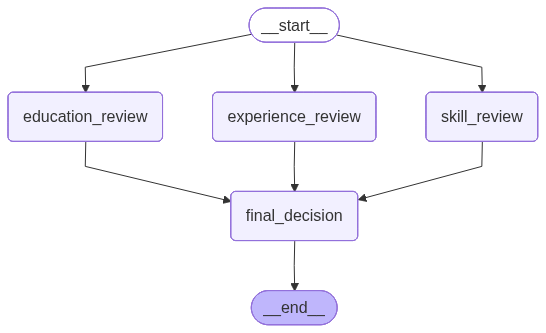

In [32]:
graph

In [48]:
initial_state = {
    "resume" :"""
        Sahil

    skills:
    Python
    Django
    Sql
    React
    restApi
    Git
    javascript

    Experience:
    1 years as Backend and Ai developer.
    Worked on Frontend Backend and database.

    Education:
    Bachelor of computer Application 
    """,

    "skill_feedback": "",
    "experience_feedback": "",
    "education_feedback": "",
    "final_decision": ""
}

In [49]:
result = graph.invoke(initial_state)

In [50]:
print("\n" + "=" * 60)
print("SKILL REVIEW")
print("=" * 60)
print(result["skill_feedback"])

print("\n" + "=" * 60)
print("EXPERIENCE REVIEW")
print("=" * 60)
print(result["experience_feedback"])

print("\n" + "=" * 60)
print("EDUCATION REVIEW")
print("=" * 60)
print(result["education_feedback"])

print("\n" + "=" * 60)
print("FINAL DECISION")
print("=" * 60)
print(result["final_decision"])


SKILL REVIEW
**Technical Skills Evaluation:**

The candidate, Sahil, has listed a range of technical skills that are relevant to full-stack development and AI. Here's a breakdown:

**Strengths:**

1. Programming languages: Python, JavaScript
2. Frameworks: Django (Backend), React (Frontend)
3. Database: SQL
4. Version control: Git
5. API development: restApi

**Observations:**

1. The candidate has a good balance of frontend and backend skills.
2. The inclusion of AI development experience suggests familiarity with machine learning concepts, although specific AI-related skills are not listed.
3. The presence of Git indicates familiarity with version control systems.

**Gaps:**

1. No specific mention of cloud platforms, containerization, or DevOps tools.
2. No indication of experience with NoSQL databases or other data storage solutions.
3. The list of skills is relatively brief, and it would be beneficial to see more specialized skills or certifications.

Overall, Sahil's technical s